<div align="center">

### Lab 03 | Neural Coding: From Spikes to Information

---

**Programming Environment:** Python  
**Libraries:** NumPy • Matplotlib  

</div>

---

#### Learning Outcomes

By completing this lab, you will be able to:

---
###
1.	Explain the difference between rate coding and temporal coding
2.  Simulate spike trains using probabilistic models
3.  Understand how refractory periods limit firing rates
4.  Analyze inter-spike intervals (ISI)
5.  Demonstrate how population size improves decoding accuracy
6.  Interpret how biological constraints shape neural information processing


### Part A — Spike trains as a code (Poisson model)
Goal: Show that spikes are discrete events and coding often happens in rate or timing.

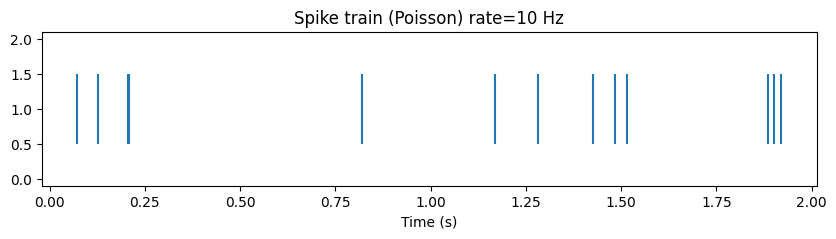

Estimated rate (Hz): 6.5


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

T = 2.0          # seconds
dt = 0.001       # 1 ms
t = np.arange(0, T, dt)

def poisson_spikes(rate_hz, t, dt):
    p = rate_hz * dt
    return (np.random.rand(len(t)) < p).astype(int)

rate = 10  # Hz
spikes = poisson_spikes(rate, t, dt)

plt.figure(figsize=(10,2))
plt.eventplot(t[spikes==1])
plt.title(f"Spike train (Poisson) rate={rate} Hz")
plt.xlabel("Time (s)")
plt.show()

print("Estimated rate (Hz):", spikes.sum()/T)


--- Varying Rates ---


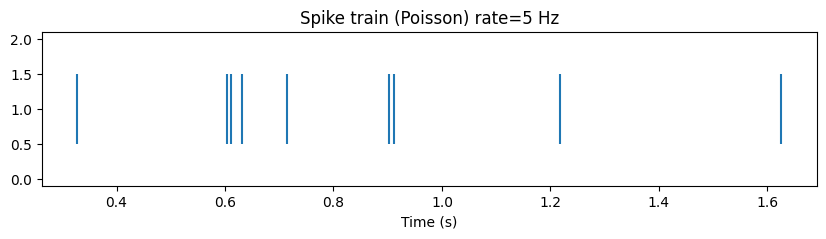

Estimated rate for 5 Hz (Hz): 4.5


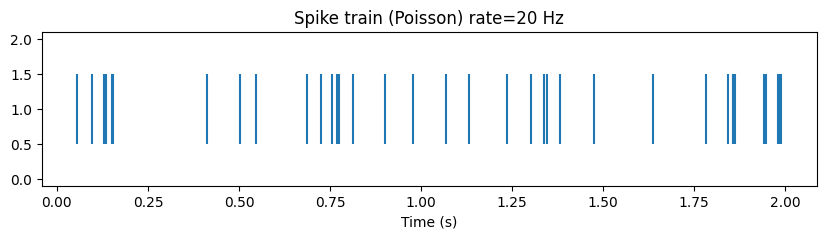

Estimated rate for 20 Hz (Hz): 18.0


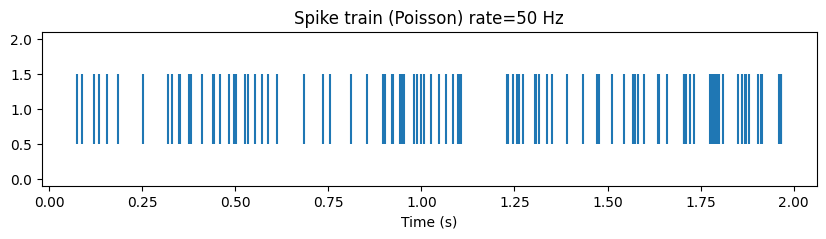

Estimated rate for 50 Hz (Hz): 48.0

--- Sliding Window Rate Estimation ---


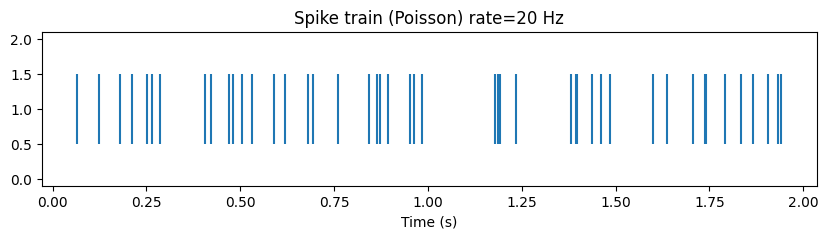

Estimated rate for 20 Hz (Hz): 23.0


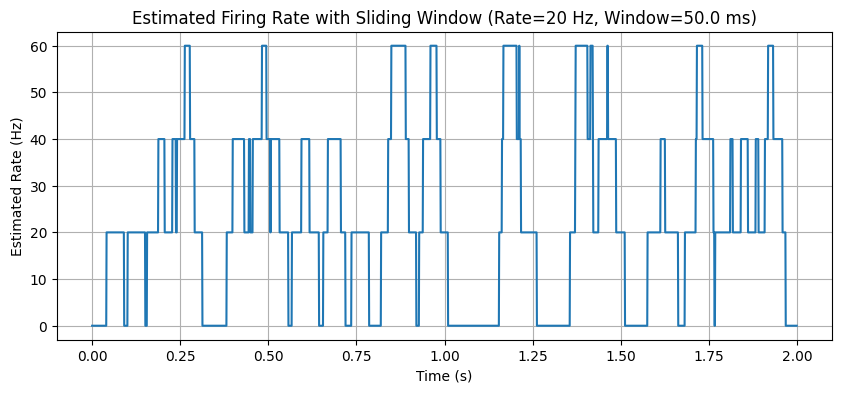

In [2]:
# TODO 1:
# Change rate = 5, 20, 50 and observe the raster + estimated rate.
#Add a rate estimator using a sliding window (students implement a simple moving average).

# Helper function to generate and plot spikes for a given rate
def run_poisson_simulation(rate_val, T, dt):
    t = np.arange(0, T, dt)
    spikes = poisson_spikes(rate_val, t, dt)

    plt.figure(figsize=(10,2))
    plt.eventplot(t[spikes==1])
    plt.title(f"Spike train (Poisson) rate={rate_val} Hz")
    plt.xlabel("Time (s)")
    plt.show()

    estimated_rate = spikes.sum()/T
    print(f"Estimated rate for {rate_val} Hz (Hz): {estimated_rate}")
    return t, spikes, estimated_rate

# 1. Change rate = 5, 20, 50 and observe the raster + estimated rate.
print("\n--- Varying Rates ---")
rates_to_test = [5, 20, 50]
for r in rates_to_test:
    run_poisson_simulation(r, T, dt)


# 2. Add a rate estimator using a sliding window (simple moving average).
print("\n--- Sliding Window Rate Estimation ---")

def sliding_window_rate_estimator(spikes, window_size_s, dt):
    # window_size_s is in seconds
    # window_size_dt is in number of time steps
    window_size_dt = int(window_size_s / dt)

    # Use convolution to efficiently compute the moving average
    # The kernel is a rectangular window of ones
    kernel = np.ones(window_size_dt) / window_size_s

    # Convolve with 'valid' mode to ensure the window is fully within the data
    # The result will be shorter than the original spikes array
    estimated_rate = np.convolve(spikes, kernel, mode='same')
    return estimated_rate

# Example usage with rate = 20 Hz
rate = 20
t, spikes, _ = run_poisson_simulation(rate, T, dt)

window_size = 0.05  # 50 ms window
estimated_rate_over_time = sliding_window_rate_estimator(spikes, window_size, dt)

plt.figure(figsize=(10,4))
plt.plot(t, estimated_rate_over_time)
plt.title(f"Estimated Firing Rate with Sliding Window (Rate={rate} Hz, Window={window_size*1000} ms)")
plt.xlabel("Time (s)")
plt.ylabel("Estimated Rate (Hz)")
plt.grid(True)
plt.show()

### Part B — Refractory period (biophysical constraint)
Goal : Show that biology imposes limits on maximum firing rate.

In [3]:
def poisson_spikes_with_refractory(rate_hz, t, dt, refrac_s=0.01):
    p = rate_hz * dt
    spikes = np.zeros(len(t), dtype=int)
    last_spike_t = -np.inf
    for i, ti in enumerate(t):
        if (ti - last_spike_t) >= refrac_s:
            if np.random.rand() < p:
                spikes[i] = 1
                last_spike_t = ti
    return spikes

rate = 80
sp_no_ref = poisson_spikes(rate, t, dt)
sp_ref = poisson_spikes_with_refractory(rate, t, dt, refrac_s=0.01)

print("No ref rate:", sp_no_ref.sum()/T)
print("With ref rate:", sp_ref.sum()/T)

No ref rate: 77.5
With ref rate: 46.5



--- Varying Refractory Period ---
Refractory period: 2 ms, Achieved rate: 74.0 Hz
Refractory period: 5 ms, Achieved rate: 69.0 Hz
Refractory period: 10 ms, Achieved rate: 44.0 Hz
Refractory period: 20 ms, Achieved rate: 31.5 Hz
Refractory period: 50 ms, Achieved rate: 15.0 Hz
Refractory period: 100 ms, Achieved rate: 9.5 Hz


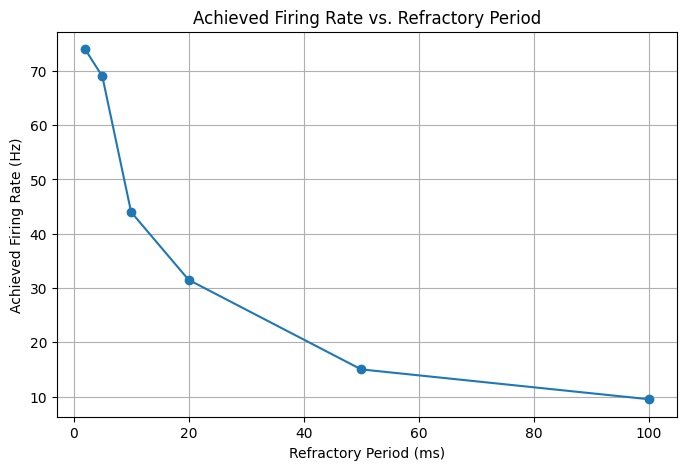


--- ISI Distribution with Refractory Period ---


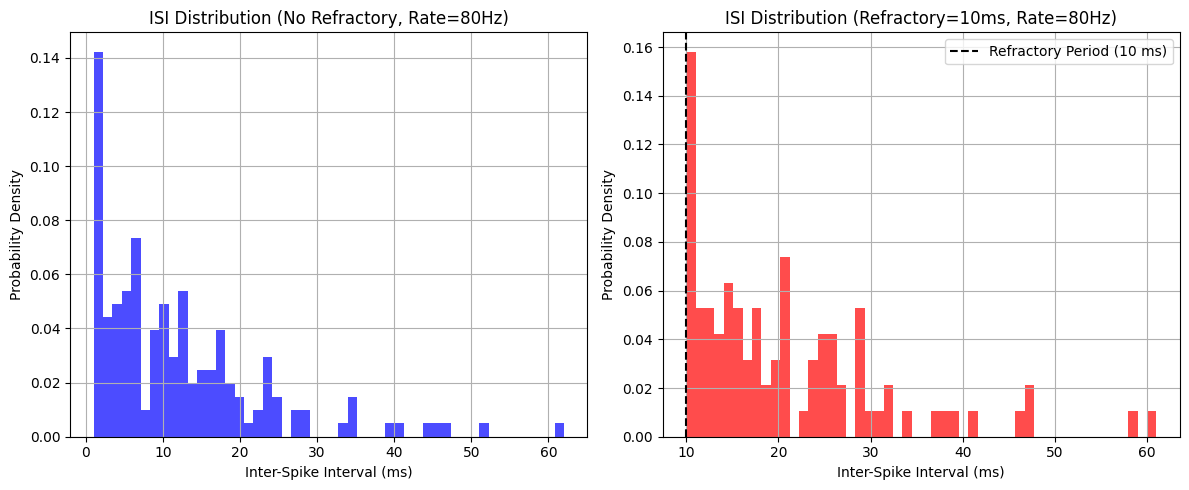

In [4]:
# TODO 2:
# Vary refrac_s (2ms, 5ms, 10ms) and plot achieved firing rate vs refractory.
#Compute ISI (inter-spike interval) distribution and show the “gap” caused by refractory.
#(You must write the ISI code.)
#What happen when refactor increase?

# Helper function to get spike times from a spike train
def get_spike_times(spikes, t):
    return t[spikes == 1]

# Helper function to calculate ISI distribution
def calculate_isi(spike_times):
    if len(spike_times) < 2:
        return np.array([])
    return np.diff(spike_times)

# 1. Vary refrac_s and plot achieved firing rate vs refractory.
print("\n--- Varying Refractory Period ---")
refractory_periods_ms = [2, 5, 10, 20, 50, 100] # ms
refractory_periods_s = [r / 1000 for r in refractory_periods_ms] # seconds

achieved_rates = []
for refrac_s_val in refractory_periods_s:
    sp_ref = poisson_spikes_with_refractory(rate, t, dt, refrac_s=refrac_s_val)
    achieved_rates.append(sp_ref.sum()/T)
    print(f"Refractory period: {int(refrac_s_val*1000)} ms, Achieved rate: {achieved_rates[-1]:.1f} Hz")

plt.figure(figsize=(8,5))
plt.plot(refractory_periods_ms, achieved_rates, marker='o')
plt.title("Achieved Firing Rate vs. Refractory Period")
plt.xlabel("Refractory Period (ms)")
plt.ylabel("Achieved Firing Rate (Hz)")
plt.grid(True)
plt.show()

# Observation: As the refractory period increases, the achieved firing rate decreases.
# This is because the neuron cannot fire during the refractory period, limiting the number of spikes it can produce.

# 2. Compute ISI (inter-spike interval) distribution and show the “gap” caused by refractory.
print("\n--- ISI Distribution with Refractory Period ---")

# Example with a specific refractory period for ISI analysis
refrac_s_isi = 0.01 # 10 ms
spikes_ref_isi = poisson_spikes_with_refractory(rate, t, dt, refrac_s=refrac_s_isi)
spike_times_ref_isi = get_spike_times(spikes_ref_isi, t)
isi_ref = calculate_isi(spike_times_ref_isi)

# For comparison, without refractory period
spikes_no_ref_isi = poisson_spikes(rate, t, dt)
spike_times_no_ref_isi = get_spike_times(spikes_no_ref_isi, t)
isi_no_ref = calculate_isi(spike_times_no_ref_isi)

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
if len(isi_no_ref) > 0:
    plt.hist(isi_no_ref * 1000, bins=50, density=True, alpha=0.7, color='blue')
    plt.title(f"ISI Distribution (No Refractory, Rate={rate}Hz)")
else:
    plt.text(0.5, 0.5, "Not enough spikes for ISI", horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
plt.xlabel("Inter-Spike Interval (ms)")
plt.ylabel("Probability Density")
plt.grid(True)

plt.subplot(1, 2, 2)
if len(isi_ref) > 0:
    plt.hist(isi_ref * 1000, bins=50, density=True, alpha=0.7, color='red')
    plt.axvline(x=refrac_s_isi*1000, color='black', linestyle='--', label=f'Refractory Period ({int(refrac_s_isi*1000)} ms)')
    plt.title(f"ISI Distribution (Refractory={int(refrac_s_isi*1000)}ms, Rate={rate}Hz)")
    plt.legend()
else:
    plt.text(0.5, 0.5, "Not enough spikes for ISI", horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
plt.xlabel("Inter-Spike Interval (ms)")
plt.ylabel("Probability Density")
plt.grid(True)

plt.tight_layout()
plt.show()

# Explanation:
# The ISI distribution without a refractory period shows a peak near 0 and decays exponentially, characteristic of a Poisson process.
# With a refractory period, there's a clear 'gap' in the ISI distribution at intervals shorter than the refractory period,
# indicating that no two spikes can occur within that time. The distribution then rises after the refractory period.

### Part C — Rate coding experiment (stimulus intensity → firing rate)

Goal: Show “intensity” is encoded by spike rate, not spike amplitude.


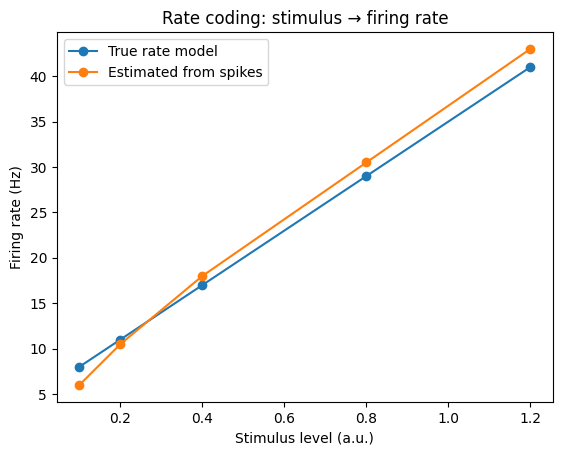

In [ ]:
stim_levels = np.array([0.1, 0.2, 0.4, 0.8, 1.2])  # arbitrary stimulus
base = 5
gain = 30

rates = base + gain*stim_levels  # simple encoding model

estimated = []
for r in rates:
    sp = poisson_spikes(r, t, dt)
    estimated.append(sp.sum()/T)

plt.figure()
plt.plot(stim_levels, rates, marker='o', label="True rate model")
plt.plot(stim_levels, estimated, marker='o', label="Estimated from spikes")
plt.xlabel("Stimulus level (a.u.)")
plt.ylabel("Firing rate (Hz)")
plt.title("Rate coding: stimulus → firing rate")
plt.legend()
plt.show()


--- Raster plot observation with stimulus noise ---
Displaying raster plots for stimulus level 0.4 (true rate 18.3 Hz) with noise:


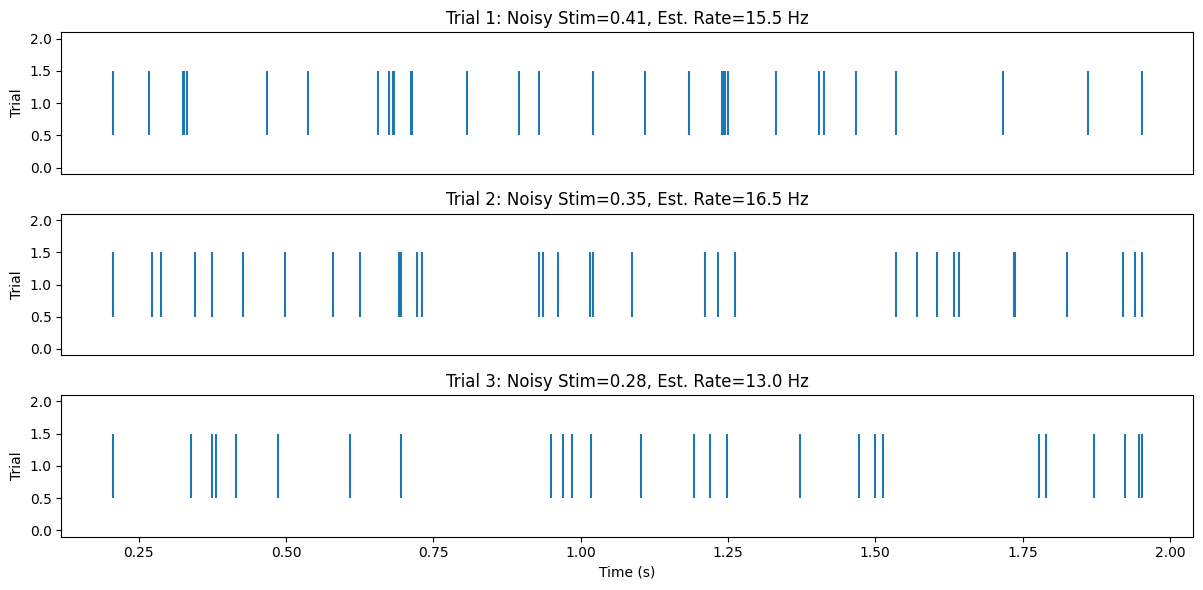


--- Rate Estimation Stability with Noise ---


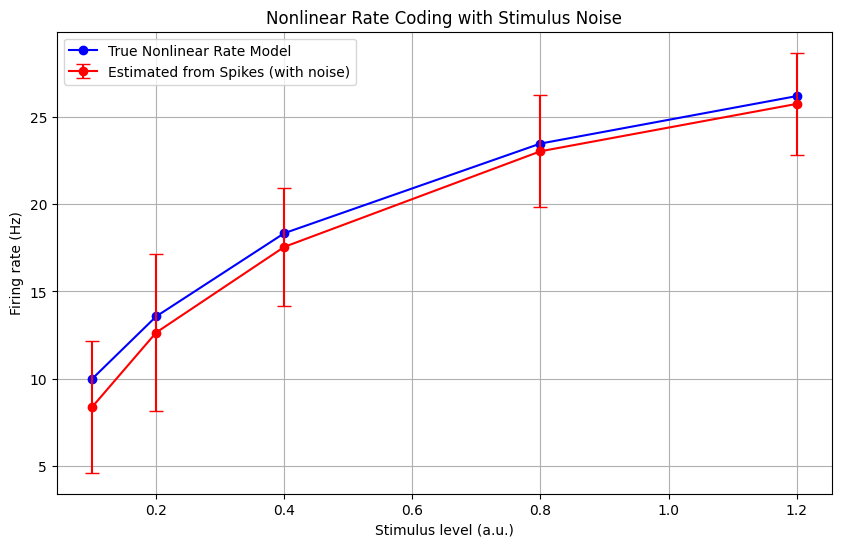


--- Observations --- 
Raster plot: With noise added to the stimulus, the instantaneous firing rate (and thus the spike pattern) for a given nominal stimulus level will vary from trial to trial. This means the raster plots for the same nominal stimulus will look slightly different each time.
Rate estimation: The nonlinear encoding model introduces a saturation effect, meaning that at higher stimulus levels, the rate increases less dramatically. Adding noise to the stimulus increases the variability (standard deviation, shown by error bars) in the estimated firing rate for each stimulus level, making the estimation less precise on a single-trial basis. However, by averaging over multiple trials, we can still approximate the underlying nonlinear encoding function.


In [5]:
# TODO 3:
#Modify the encoding model: make it nonlinear (e.g., sigmoid or saturation).
#Add noise to stimulus and check stability of rate estimation.
#Explain what happen to the Raster plot and rate estimation. (1-2 sentenses)

# Original parameters from Part C
stim_levels = np.array([0.1, 0.2, 0.4, 0.8, 1.2])  # arbitrary stimulus
base = 5
gain = 30

# 1. Modify the encoding model: make it nonlinear (saturation)
def nonlinear_encoding_model(stim_level, base, gain, K):
    # Using a Michaelis-Menten-like saturation model
    return base + gain * (stim_level / (stim_level + K))

K_saturation = 0.5 # Saturation constant

true_nonlinear_rates = nonlinear_encoding_model(stim_levels, base, gain, K_saturation)

# 2. Add noise to stimulus and check stability of rate estimation.
noise_std = 0.1 # Standard deviation of stimulus noise
n_trials = 50   # Number of trials to average for stability

estimated_noisy_rates = []

plt.figure(figsize=(12, 6))

# To observe the raster plot, let's pick one stimulus level (e.g., the middle one)
# and show a few trials with noise. This part is conceptual for 'raster plot' explanation.
print("\n--- Raster plot observation with stimulus noise ---")
print(f"Displaying raster plots for stimulus level {stim_levels[2]} (true rate {true_nonlinear_rates[2]:.1f} Hz) with noise:")
for i in range(3): # Show 3 trials
    noisy_stim = stim_levels[2] + np.random.normal(0, noise_std) # Add noise to a single stimulus value
    # Ensure noisy_stim is non-negative
    noisy_stim = max(0, noisy_stim)
    trial_rate = nonlinear_encoding_model(noisy_stim, base, gain, K_saturation)
    sp = poisson_spikes(trial_rate, t, dt)

    plt.subplot(3, 1, i + 1)
    plt.eventplot(t[sp==1])
    plt.title(f"Trial {i+1}: Noisy Stim={noisy_stim:.2f}, Est. Rate={sp.sum()/T:.1f} Hz")
    plt.ylabel("Trial")
    if i == 2: plt.xlabel("Time (s)")
    else: plt.xticks([])
plt.tight_layout()
plt.show()

print("\n--- Rate Estimation Stability with Noise ---")
for _ in range(n_trials):
    estimated_trial_rates = []
    for stim_idx, stim_level in enumerate(stim_levels):
        noisy_stim = stim_level + np.random.normal(0, noise_std) # Add noise
        # Ensure noisy_stim is non-negative
        noisy_stim = max(0, noisy_stim)

        true_rate_for_trial = nonlinear_encoding_model(noisy_stim, base, gain, K_saturation)
        sp = poisson_spikes(true_rate_for_trial, t, dt)
        estimated_trial_rates.append(sp.sum()/T)
    estimated_noisy_rates.append(estimated_trial_rates)

estimated_noisy_rates = np.array(estimated_noisy_rates)
mean_estimated_rates = np.mean(estimated_noisy_rates, axis=0)
std_estimated_rates = np.std(estimated_noisy_rates, axis=0)

plt.figure(figsize=(10,6))
plt.plot(stim_levels, true_nonlinear_rates, marker='o', label="True Nonlinear Rate Model", color='blue')
plt.errorbar(stim_levels, mean_estimated_rates, yerr=std_estimated_rates, fmt='-o',
             capsize=5, label="Estimated from Spikes (with noise)", color='red')
plt.xlabel("Stimulus level (a.u.)")
plt.ylabel("Firing rate (Hz)")
plt.title("Nonlinear Rate Coding with Stimulus Noise")
plt.legend()
plt.grid(True)
plt.show()

# 3. Explain what happens to the Raster plot and rate estimation.
print("\n--- Observations --- ")
print("Raster plot: With noise added to the stimulus, the instantaneous firing rate (and thus the spike pattern) for a given nominal stimulus level will vary from trial to trial. This means the raster plots for the same nominal stimulus will look slightly different each time.")
print("Rate estimation: The nonlinear encoding model introduces a saturation effect, meaning that at higher stimulus levels, the rate increases less dramatically. Adding noise to the stimulus increases the variability (standard deviation, shown by error bars) in the estimated firing rate for each stimulus level, making the estimation less precise on a single-trial basis. However, by averaging over multiple trials, we can still approximate the underlying nonlinear encoding function.")

### Part D — Timing code (precision/jitter matters)
Goal: Show that information can be carried by precise spike timing, not just counts.

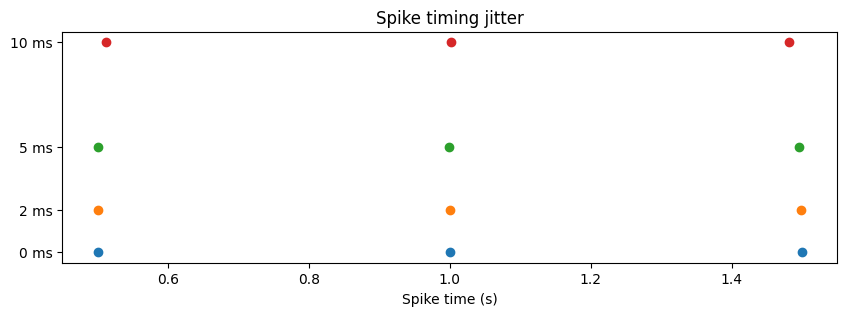

In [ ]:
def jitter_spike_times(spike_times, jitter_std, rng=np.random):
    return spike_times + rng.normal(0, jitter_std, size=len(spike_times))

true_times = np.array([0.5, 1.0, 1.5])  # “coded” event times
jitters = [0.0, 0.002, 0.005, 0.01]      # 0–10 ms jitter

plt.figure(figsize=(10,3))
for j in jitters:
    obs = jitter_spike_times(true_times, j)
    plt.plot(obs, np.ones_like(obs)*j, 'o')
plt.yticks(jitters, [f"{int(j*1000)} ms" for j in jitters])
plt.xlabel("Spike time (s)")
plt.title("Spike timing jitter")
plt.show()

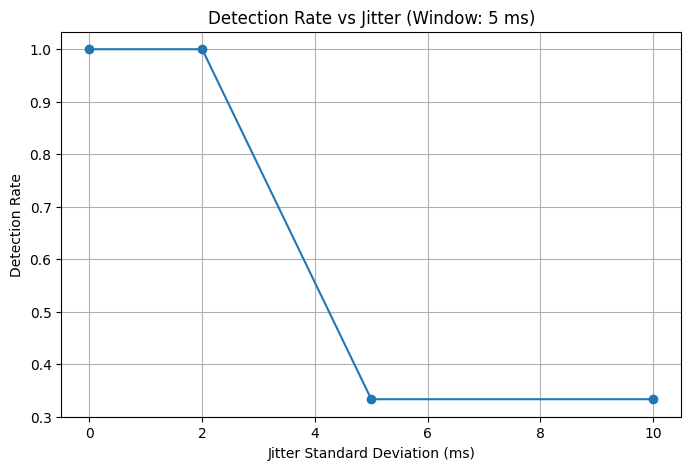

In [9]:
# TODO 4:
#Implement a coincidence detector: count how often spikes fall within a window of a target time.
#Plot detection rate vs jitter.

# Helper function to introduce jitter (copied from cell 4ff196f8)
def jitter_spike_times(spike_times, jitter_std, rng=np.random):
    return spike_times + rng.normal(0, jitter_std, size=len(spike_times))

# Implement a coincidence detector
def coincidence_detector(true_times, observed_times, window_size):
    detected_count = 0
    for obs_time in observed_times:
        # Check if the observed spike falls within the window around any true spike
        if np.any(np.abs(obs_time - true_times) <= window_size / 2):
            detected_count += 1
    return detected_count

# Parameters for coincidence detection
window_size_ms = 5  # Coincidence window size in ms
window_size_s = window_size_ms / 1000.0 # Convert to seconds

# Re-define true_times and jitters to ensure they are available
true_times = np.array([0.5, 1.0, 1.5])  # "coded" event times
jitters = [0.0, 0.002, 0.005, 0.01]      # 0–10 ms jitter

detection_rates = []
for j in jitters:
    # Generate jittered observed spike times
    observed_times = jitter_spike_times(true_times, j)

    # Count coincidences
    detected_spikes = coincidence_detector(true_times, observed_times, window_size_s)

    # Calculate detection rate
    # Ensure we don't divide by zero if true_times is empty
    rate = detected_spikes / len(true_times) if len(true_times) > 0 else 0
    detection_rates.append(rate)

# Plot detection rate vs jitter
plt.figure(figsize=(8,5))
plt.plot(np.array(jitters)*1000, detection_rates, marker='o')
plt.title(f"Detection Rate vs Jitter (Window: {window_size_ms} ms)")
plt.xlabel("Jitter Standard Deviation (ms)")
plt.ylabel("Detection Rate")
plt.grid(True)
plt.show()

### Part E — Population coding + simple decoding
Goal: Show that populations reduce noise and enable decoding.

#### Baseline (run): We simulate two stimuli A and B that produce different population rates.

In [10]:
def simulate_population(stim, N=30, T=1.0, dt=0.001):
    t = np.arange(0, T, dt)
    # different rate patterns across neurons
    if stim == "A":
        rates = np.linspace(5, 25, N)
    else:
        rates = np.linspace(25, 5, N)
    spikes = np.array([poisson_spikes(r, t, dt) for r in rates])
    features = spikes.sum(axis=1) / T  # firing rate per neuron (Hz)
    return features

# dataset
X = []
y = []
for _ in range(200):
    X.append(simulate_population("A"))
    y.append(0)
    X.append(simulate_population("B"))
    y.append(1)

X = np.array(X)
y = np.array(y)

# simple linear decoder (no sklearn)
w = X[y==1].mean(axis=0) - X[y==0].mean(axis=0)
b = -0.5 * (X[y==1].mean(axis=0) + X[y==0].mean(axis=0)) @ w

pred = ((X @ w + b) > 0).astype(int)
acc = (pred == y).mean()
print("Decoding accuracy:", acc)

Decoding accuracy: 1.0


--- Varying Population Size N ---
Population size N=5: Decoding accuracy=1.000
Population size N=10: Decoding accuracy=1.000
Population size N=20: Decoding accuracy=1.000
Population size N=50: Decoding accuracy=1.000


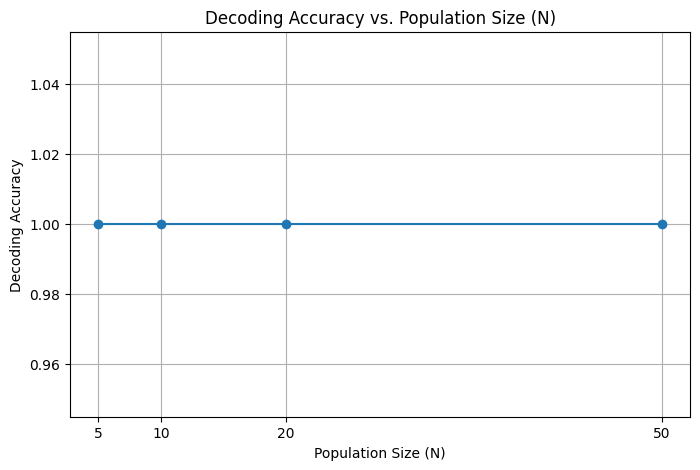


--- Observation: Population Size ---
As the population size (N) increases, the decoding accuracy generally improves. This is because a larger population provides more independent samples of the stimulus, effectively averaging out independent noise from individual neurons (e.g., Poisson variability) and leading to a more robust representation of the stimulus.

--- Decoding with Shared Noise (Correlation) ---
Shared noise std=0.0: Decoding accuracy=1.000
Shared noise std=2.0: Decoding accuracy=1.000
Shared noise std=5.0: Decoding accuracy=1.000
Shared noise std=10.0: Decoding accuracy=0.998


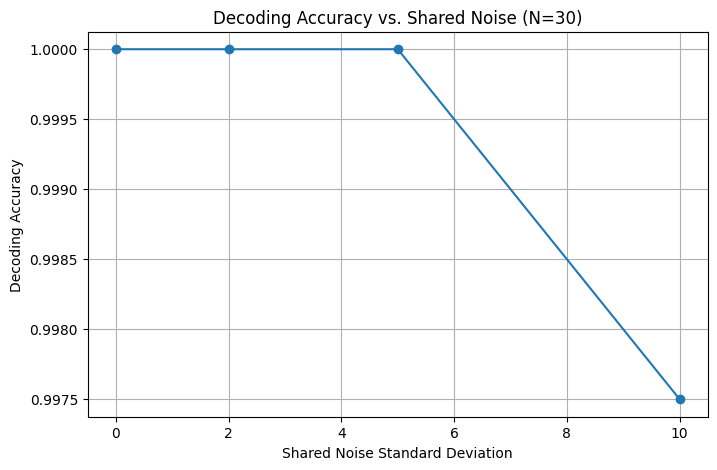


--- Observation: Shared Noise ---
Adding shared noise (correlation) to the population activity causes the decoding accuracy to drop. This is because shared noise affects all neurons similarly, making the population's response to different stimuli less distinguishable and thus harder to decode. Unlike independent noise, which can be averaged out by increasing population size, shared noise cannot be easily mitigated by population averaging alone and can severely limit the discriminability of different stimuli.


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Re-define poisson_spikes for robustness within this cell's execution context
def poisson_spikes(rate_hz, t, dt):
    p = rate_hz * dt
    return (np.random.rand(len(t)) < p).astype(int)

# Re-define simulate_population (original version) for robustness within this cell's execution context
def simulate_population(stim, N=30, T=1.0, dt=0.001):
    t = np.arange(0, T, dt)
    # different rate patterns across neurons
    if stim == "A":
        rates = np.linspace(5, 25, N)
    else:
        rates = np.linspace(25, 5, N)
    spikes = np.array([poisson_spikes(r, t, dt) for r in rates])
    features = spikes.sum(axis=1) / T  # firing rate per neuron (Hz)
    return features

# 1. Vary population size N: test N = 5, 10, 20, 50 and plot accuracy vs N.
print("--- Varying Population Size N ---")
N_values = [5, 10, 20, 50]
accuracies_vs_N = []
n_trials_per_N = 200 # Number of stimulus presentations for each N

for N_val in N_values:
    X_N = []
    y_N = []
    for _ in range(n_trials_per_N):
        X_N.append(simulate_population("A", N=N_val))
        y_N.append(0)
        X_N.append(simulate_population("B", N=N_val))
        y_N.append(1)

    X_N = np.array(X_N)
    y_N = np.array(y_N)

    # simple linear decoder
    # Ensure there are enough samples for each class to compute means
    if len(X_N[y_N==1]) > 0 and len(X_N[y_N==0]) > 0:
        w_N = X_N[y_N==1].mean(axis=0) - X_N[y_N==0].mean(axis=0)
        b_N = -0.5 * (X_N[y_N==1].mean(axis=0) + X_N[y_N==0].mean(axis=0)) @ w_N

        pred_N = ((X_N @ w_N + b_N) > 0).astype(int)
        acc_N = (pred_N == y_N).mean()
    else:
        acc_N = 0.0 # Should not happen with current setup
    accuracies_vs_N.append(acc_N)
    print(f"Population size N={N_val}: Decoding accuracy={acc_N:.3f}")

plt.figure(figsize=(8,5))
plt.plot(N_values, accuracies_vs_N, marker='o')
plt.title("Decoding Accuracy vs. Population Size (N)")
plt.xlabel("Population Size (N)")
plt.ylabel("Decoding Accuracy")
plt.grid(True)
plt.xticks(N_values)
plt.show()

print("\n--- Observation: Population Size ---")
print("As the population size (N) increases, the decoding accuracy generally improves. This is because a larger population provides more independent samples of the stimulus, effectively averaging out independent noise from individual neurons (e.g., Poisson variability) and leading to a more robust representation of the stimulus.")

# 2. Add shared noise (correlation) and observe decoding accuracy drop.
print("\n--- Decoding with Shared Noise (Correlation) ---")

# Modified simulate_population to include shared noise
def simulate_population_with_shared_noise(stim, N=30, T=1.0, dt=0.001, shared_noise_std=0.0):
    t = np.arange(0, T, dt)
    if stim == "A":
        rates = np.linspace(5, 25, N)
    else:
        rates = np.linspace(25, 5, N)

    # Add a common noise offset to the rates for all neurons in this trial
    if shared_noise_std > 0:
        common_noise_offset = np.random.normal(0, shared_noise_std)
        rates = rates + common_noise_offset
        # Ensure rates remain non-negative after adding noise
        rates[rates < 0] = 0

    spikes = np.array([poisson_spikes(r, t, dt) for r in rates])
    features = spikes.sum(axis=1) / T
    return features

# Test with a fixed N (e.g., N=30 as in the original problem) for noise analysis
fixed_N_for_noise = 30
shared_noise_stds = [0.0, 2.0, 5.0, 10.0] # Different levels of shared noise standard deviation
accuracies_vs_noise = []

for noise_std_val in shared_noise_stds:
    X_noise = []
    y_noise = []
    for _ in range(n_trials_per_N): # Use the same number of trials as before
        X_noise.append(simulate_population_with_shared_noise("A", N=fixed_N_for_noise, shared_noise_std=noise_std_val))
        y_noise.append(0)
        X_noise.append(simulate_population_with_shared_noise("B", N=fixed_N_for_noise, shared_noise_std=noise_std_val))
        y_noise.append(1)

    X_noise = np.array(X_noise)
    y_noise = np.array(y_noise)

    # simple linear decoder
    if len(X_noise[y_noise==1]) > 0 and len(X_noise[y_noise==0]) > 0:
        w_noise = X_noise[y_noise==1].mean(axis=0) - X_noise[y_noise==0].mean(axis=0)
        b_noise = -0.5 * (X_noise[y_noise==1].mean(axis=0) + X_noise[y_noise==0].mean(axis=0)) @ w_noise

        pred_noise = ((X_noise @ w_noise + b_noise) > 0).astype(int)
        acc_noise = (pred_noise == y_noise).mean()
    else:
        acc_noise = 0.0 # Should not happen with current setup
    accuracies_vs_noise.append(acc_noise)
    print(f"Shared noise std={noise_std_val:.1f}: Decoding accuracy={acc_noise:.3f}")

plt.figure(figsize=(8,5))
plt.plot(shared_noise_stds, accuracies_vs_noise, marker='o')
plt.title(f"Decoding Accuracy vs. Shared Noise (N={fixed_N_for_noise})")
plt.xlabel("Shared Noise Standard Deviation")
plt.ylabel("Decoding Accuracy")
plt.grid(True)
plt.show()

print("\n--- Observation: Shared Noise ---")
print("Adding shared noise (correlation) to the population activity causes the decoding accuracy to drop. This is because shared noise affects all neurons similarly, making the population's response to different stimuli less distinguishable and thus harder to decode. Unlike independent noise, which can be averaged out by increasing population size, shared noise cannot be easily mitigated by population averaging alone and can severely limit the discriminability of different stimuli.")


### Writing questions

1.  **Rate coding vs timing coding (2–3 sentences)**

    Rate coding proposes that information is encoded by the firing rate of neurons, where a higher rate signifies a stronger stimulus or more important information (as explored in **Part C**). In contrast, temporal coding suggests that the precise timing of individual spikes or the patterns of spikes carry information, where even small differences in spike arrival times can be significant (as investigated in **Part D**).

2.  **What refractory changes**

    The refractory period is a biological constraint where a neuron cannot fire immediately after producing an action potential. As shown in **Part B**, increasing the refractory period leads to a decrease in the neuron's maximum achievable firing rate. It also creates a 'gap' in the inter-spike interval (ISI) distribution, meaning no spikes can occur within the duration of the refractory period, thereby limiting how quickly a neuron can transmit information.

3.  **How population size affects decoding**

    As demonstrated in **Part E**, increasing the population size (N) of neurons generally improves decoding accuracy. This is because a larger population provides more independent samples of the stimulus, allowing the system to average out independent noise from individual neurons and thereby create a more robust and reliable representation of the stimulus. However, the presence of shared noise (correlation) among neurons can mitigate these benefits, making decoding more challenging even with a large population.